In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import tree

In [ ]:
df = pd.read_csv('/content/AB_NYC_2019.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

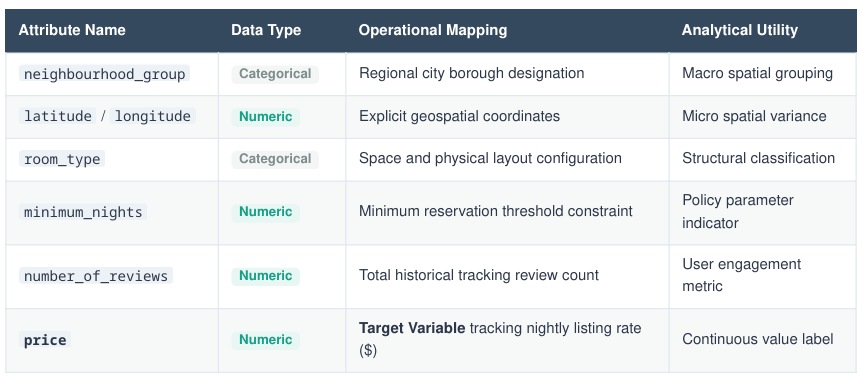

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# only null values
null_vals = df.isnull().sum()
null_vals[null_vals>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [ ]:
# percentage of null values
null_percent = (null_vals / len(df)) * 100
null_percent[null_percent>0]

,0
name,0.032723
host_name,0.042949
last_review,20.558339
reviews_per_month,20.558339


In [ ]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [ ]:
# unique values counts
df['name'].value_counts()

,count
name,
Hillside Hotel,18
Home away from home,17
New york Multi-unit building,16
Brooklyn Apartment,12
Private Room,11
...,...
Spacious Modern Alcove Studio in a Luxury Building,1
Artist's Room in Large Apartment,1
Modern Oasis in Central Park Slope,1


In [ ]:
df['host_name'].value_counts()

,count
host_name,
Michael,417
David,403
Sonder (NYC),327
John,294
Alex,279
...,...
Pujan,1
Raheem,1
Rusaa,1


In [ ]:
# replacing null with most repeated value
df['host_name'] = df['host_name'].fillna(df['host_name'].mode()[0])
df['host_name'].isnull().sum()

np.int64(0)

In [ ]:
# replacing null by unknown
df['name'] = df['name'].fillna('unknown')
df['name'].isnull().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [ ]:
# null with "no review"
df['last_review'] = df['last_review'].fillna('No Review')
df['last_review'].isnull().sum()

np.int64(0)

In [ ]:
# null values by 0.0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)
df['reviews_per_month'].isnull().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# figuring out numeric and categorical values seperately
num_col = list(df.describe().columns)
cat_col = []
for i in df.columns:
  if i not in num_col:
    cat_col.append(i)

print('Numeric columns : \t', num_col)
print('Categorical columns : \t', cat_col)

Numeric columns : 	 ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical columns : 	 ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


In [ ]:
# count of unique cat columns
for i in cat_col:
  print(i)
  print(df[i].value_counts())

name
name
Hillside Hotel                                        18
Home away from home                                   17
New york Multi-unit building                          16
unknown                                               16
Brooklyn Apartment                                    12
                                                      ..
Spacious Modern Alcove Studio in a Luxury Building     1
Artist's Room in Large Apartment                       1
Modern Oasis in Central Park Slope                     1
One BR upper east, walk out to garden                  1
ASTORIA APARTMENT OUTDOOR SPACE                        1
Name: count, Length: 47906, dtype: int64
host_name
host_name
Michael          438
David            403
Sonder (NYC)     327
John             294
Alex             279
                ... 
Pujan              1
Raheem             1
Rusaa              1
Erin At Bedly      1
Brad & Rachel      1
Name: count, Length: 11452, dtype: int64
neighbourhood_group
neighbourh

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# Check correlation matrix
correlation = df.corr(numeric_only=True)
print(correlation['price'].sort_values(ascending=False))

price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
host_id                           0.015309
id                                0.010619
number_of_reviews                -0.047954
reviews_per_month                -0.050564
longitude                        -0.150019
Name: price, dtype: float64


In [ ]:
# Filter out extreme price outliers
df_clean = df[(df['price'] >= 10) & (df['price'] <= 500)].copy()
feature = df_clean.drop(columns=['price', 'id', 'name', 'host_id', 'host_name', 'neighbourhood', 'last_review'])
target = df_clean['price']
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [ ]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


In [ ]:
df['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Define the Transformer
trans = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['room_type', 'neighbourhood_group'])
    ],
    remainder='passthrough'
)

# Create a Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', trans),
    ('regressor', DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42))
])
model_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['room_type',
                                                   'neighbourhood_group'])])),
                ('regressor',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=20,
                                       random_state=42))])

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
# Make predictions
y_pred = model_pipeline.predict(x_test)

# Evaluate
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

Test R2 Score: 0.4433
MAE: 43.96


In [ ]:
y_train_pred = model_pipeline.predict(x_train)
y_test_pred = model_pipeline.predict(x_test)

# Calculate scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score:  {test_r2:.4f}")

Training R2 Score: 0.4405
Testing R2 Score:  0.4433


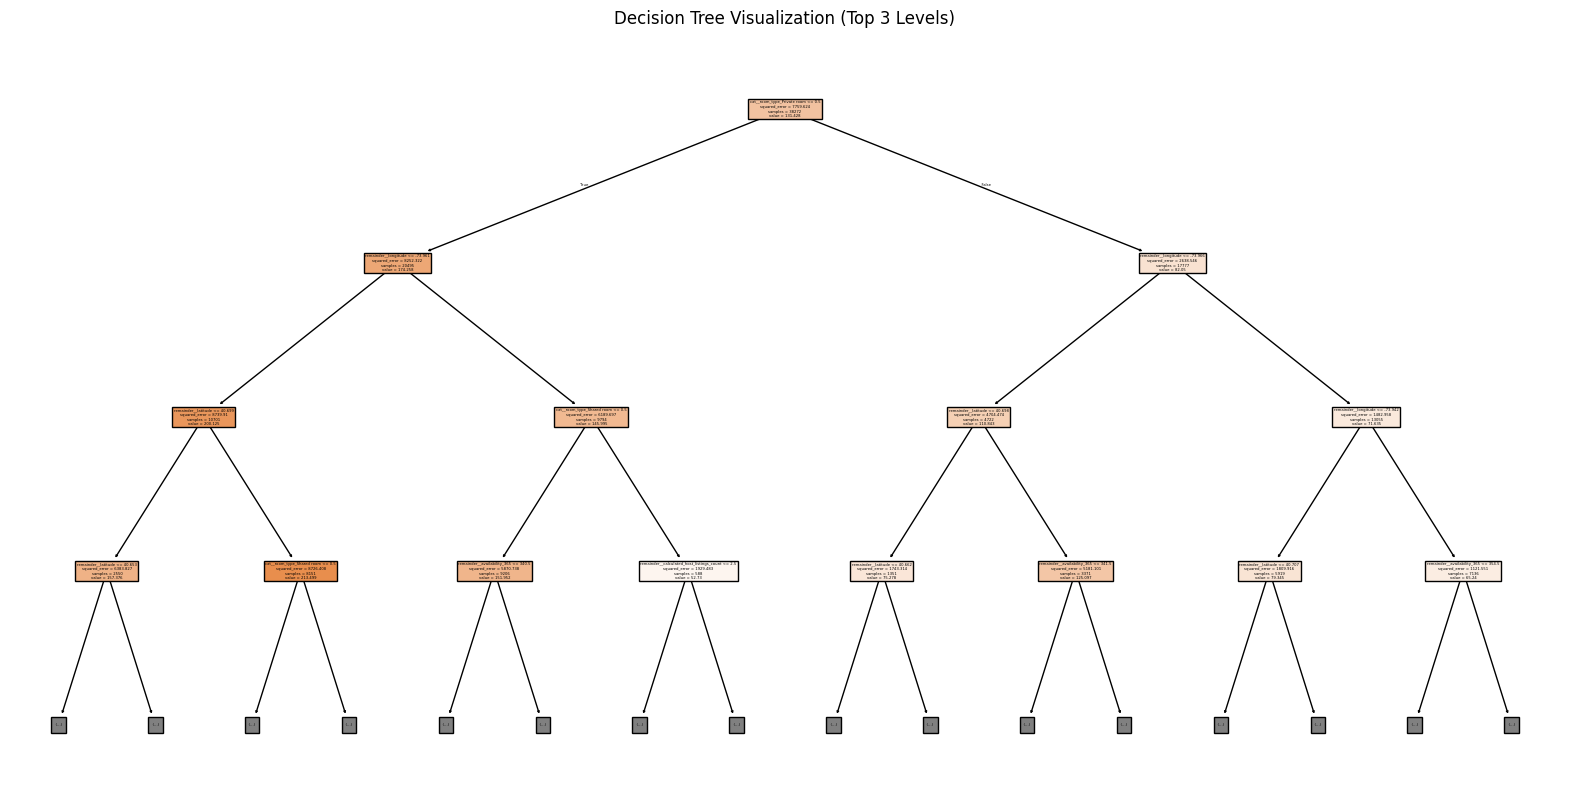

In [ ]:
# Extract the decision tree from your pipeline
tree_model = model_pipeline.named_steps['regressor']
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Plot the tree
plt.figure(figsize=(20, 10))  # Makes the plot large enough to read
tree.plot_tree(tree_model, feature_names=list(feature_names),
    filled=True, max_depth=3,
)
plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()